 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - MSc/PGDip in Big Data Analytics & Artificial Intelligence*

# *Introduction to Computer Vision*



# Image Processing

### Blending & Pasting Images
This is particularly useful if you would like to synthetically augment a dataset or highlight something within an image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import cv2

# Load Image
img1 = cv2.imread('atu.jpg')
img2 = cv2.imread('newcourses.jpg')

#Set both images to RGB
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

[ WARN:0@0.022] global loadsave.cpp:278 findDecoder imread_('atu.jpg'): can't open/read file: check file path/integrity
[ WARN:0@0.023] global loadsave.cpp:278 findDecoder imread_('newcourses.jpg'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /Users/macmini_16g/GHA-Actions-Opencv-Python/_work/opencv-python/opencv-python/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


In [ ]:
plt.imshow(img1)

In [ ]:
plt.imshow(img2)

In [ ]:
#Both these images are the same size so it is easy to blend the images together.
blended = cv2.addWeighted(src1=img1,alpha=0.4,src2=img2,beta=0.6,gamma=0) #Try changing the alpha and beta value.
plt.imshow(blended)

That works great if the images are the same size, but what happens if they are different sizes?
You will get an error using the cv2.addWeighted function - "Sizes of input arguments do not match".

In [ ]:
img2 = cv2.imread('compcourses.png')

plt.imshow(img2) #Smaller image loaded.

In [ ]:
bigimg = img1
smallimg = img2

# Define the top-left corner of where we want to place the small image
x_offset=256 #Width
y_offset=192 #Height

# Paste small image on top of big image
# smallimg.shape[0] = height of small image
# smallimg.shape[1] = width of the small image
bigimg[y_offset:y_offset+smallimg.shape[0], x_offset:x_offset+smallimg.shape[1]] = smallimg
plt.imshow(bigimg)

So we were able to paste a smaller image on top of a bigger image, but this isn't as natural is the blending effect previously performed. We can do this with different size image but it means using an ROI (Region Of Interest) and creating a mask. This will invole multiple steps.

## Region of Interest


In [ ]:
img1 = cv2.imread('atu.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img1.shape

In [ ]:
img2.shape

In [ ]:
# subtract the x/y values of small and big image
x_offset=512-256
y_offset=384-192
roi = img1[y_offset:384,x_offset:512] # BOTTOM RIGHT CORNER
plt.imshow(roi)

## Creating masks
Using bitwise_or operation on images: https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html


In [ ]:
# convert the compcourses.png to gray to allow a mask to be created based on intensity
img2grayscale = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)
plt.imshow(img2grayscale,cmap='gray')

## Bitwise
Apply arithmetic operations to images.
Check out the documentation : https://docs.opencv.org/4.x/d0/d86/tutorial_py_image_arithmetics.html

In [ ]:
#Inverse Mask - indicates where to remove the background or only keep part of the image
mask_inv = cv2.bitwise_not(img2grayscale) #Inverse Mask
plt.imshow(mask_inv,cmap='gray')

In [ ]:
# Create a white image in same size as img2
white_background = np.full(img2.shape, 255, dtype=np.uint8)
# apply a 'bitwise_or' on 2 images
# Take the white_background image. Copy its pixels only where mask_inv is non-zero.
# All other pixels in the result (bk) will be black (0).
bk = cv2.bitwise_or(white_background, white_background, mask=mask_inv)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed
axes[0].imshow(white_background)
axes[0].set_title('white_background')
axes[0].axis('off')

axes[1].imshow(mask_inv)
axes[1].set_title('mask_inv')
axes[1].axis('off')

axes[2].imshow(bk)
axes[2].set_title('bk - bitwise_or')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Bring back the Colour

In [ ]:
# copies only the pixels from img2 where mask_inv is not zero, and sets the rest to black.
colour = cv2.bitwise_or(img2, img2, mask=mask_inv)
# plt.imshow(colour)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Adjust figsize as needed
axes[0].imshow(img2)
axes[0].set_title('img2')
axes[0].axis('off')

axes[1].imshow(mask_inv)
axes[1].set_title('mask_inv')
axes[1].axis('off')

axes[2].imshow(colour)
axes[2].set_title('colour')
axes[2].axis('off')

plt.tight_layout()
plt.show()

### Blend Mask with ROI


In [ ]:
#  Blend the 2 images by applying bitwise_or between the images values
final_roi = cv2.bitwise_or(roi,colour)
plt.imshow(final_roi)

Now it is time to add this smaller image to the larger image by pasting it like we did before.

In [ ]:
bigimg = img1
smallimg = final_roi

# Paste small image on top of big image
bigimg[y_offset:y_offset+smallimg.shape[0], x_offset:x_offset+smallimg.shape[1]] = smallimg

plt.imshow(bigimg)

### Student Exercise 1

a). Describe what is happening in the masking of images.  <br>
b). Using  two images of your choice apply a similiar masking of photo with some blending  <br>
c). Instead of blending image2 into the bottom right of the image try blending it into the top left. It will be easier than this!

In [ ]:
# code here

### Student Exercise 2

Using the techniques learned above and apply independent learning to achieve the blended image below using *wolf.png* and *wolf2.png*

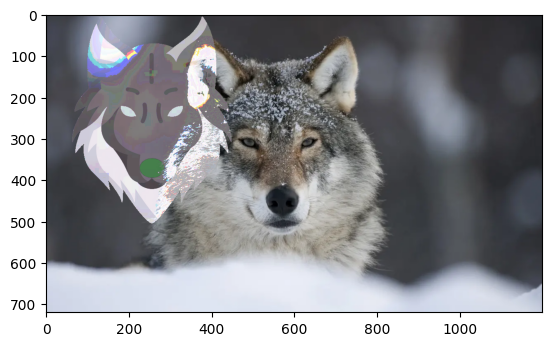

In [ ]:
# Code here

# Image Operations

## Blurring

In [ ]:
img1 = cv2.imread('atufront.jpg')

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
font = cv2.FONT_HERSHEY_COMPLEX
cv2.putText(img1,text='ATU',org=(30,90), fontFace=font,fontScale= 3,color=(0,0,0),thickness=1)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.imshow(img1)

### 2D Convolution

Doc: https://docs.opencv.org/4.11.0/d4/d86/group__imgproc__filter.html#ga27c049795ce870216ddfb366086b5a04

In [ ]:
# Explore these values, change them and see the impact on the image.
kernel = np.ones(shape=(3,3),dtype=np.float32)/10
#-1 is automatically assigning the output depth to be the same as the input depth.
blurredimg = cv2.filter2D(img1,-1,kernel)

#Display Image
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.imshow(blurredimg)

### OpenCV Blur Function

In [ ]:
#The shape of the kernel can be changed. The higher the value, the image will be more blurred.
blurredimg = cv2.blur(img1, ksize=(2,2)) 

#Display Image
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.imshow(blurredimg)

### Gaussian Blur

In [ ]:
#Change the sigma value from 10 and the kernel shape to see if this has an impact.
blurredimg = cv2.GaussianBlur(img1,(3,3),10)

#Display Image
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111)
ax.imshow(blurredimg)

### Median Blur on Noisy Image

In [ ]:
notnoisy = cv2.imread('atufront.jpg')
noisy = cv2.imread('atufrontnoisy.jpg')

notnoisy = cv2.cvtColor(notnoisy, cv2.COLOR_BGR2RGB)
noisy = cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(15,12))
ax1 = fig.add_subplot(1,2,1)
ax1.imshow(notnoisy)
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(noisy)

In [ ]:
notnoisy.mean() #This image has a min of 0 and a max of 255.

In [ ]:
median = cv2.medianBlur(noisy,5)

fig = plt.figure(figsize=(15,12))
ax1 = fig.add_subplot(1,2,1)
# Display the 2 images
ax1.imshow(noisy)
ax2 = fig.add_subplot(1,2,2)
ax2.imshow(median)

## Thresholding
Thresholding is a way to turn a complex image into something much simpler—usually just black and white—so a computer can understand it more easily.

Every image is made up of pixels. Thresholding picks a cutoff value (called a threshold). <br>
Then it checks every pixel and if the pixel is brighter than the threshold, it becomes white, iIf it’s darker, it becomes black
 
**Uses**: Used a lot in everyday technology as it helps to seperate the background noise., i.e. it turns it into clean black text on a white background. Used a lot in Adobe Scan or Microsoft Lens

In [ ]:
rainbow = cv2.imread('rainbow.jpg')
rainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB)
# 0 for Black & White Image
bwrainbow = cv2.imread('rainbow.jpg',0)

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
plt.title('Colour', fontsize=10)
ax1.imshow(rainbow)
ax2 = fig.add_subplot(1,2,2)
plt.title('Black & White', fontsize=10)
ax2.imshow(bwrainbow,cmap='gray')

### Different types of Threshold

In a binary threshold we set a threshold value and determine that any value below this threshold is set to 0 and any value above is set to the max value.

In [ ]:
#127 is the half way point between 0 and 255.
binarythresh = cv2.threshold(bwrainbow,127,255,cv2.THRESH_BINARY) 
inversethresh = cv2.threshold(bwrainbow,127,255,cv2.THRESH_BINARY_INV)
threshtrunc = cv2.threshold(bwrainbow,127,255,cv2.THRESH_TRUNC)
threshtozero = cv2.threshold(bwrainbow,127,255,cv2.THRESH_TOZERO)
inversethreshtozero = cv2.threshold(bwrainbow,127,255,cv2.THRESH_TOZERO_INV)

fig = plt.figure(figsize=(20,35))
ax1 = fig.add_subplot(1,5,1)
plt.title('Binary Threshold', fontsize=10)
ax1.imshow(binarythresh[1],cmap='gray')
ax2 = fig.add_subplot(1,5,2)
plt.title('Inverse Threshold', fontsize=10)
ax2.imshow(inversethresh[1],cmap='gray')
ax3 = fig.add_subplot(1,5,3)
plt.title('Threshold Truncation', fontsize=10)
ax3.imshow(threshtrunc[1],cmap='gray')
ax4 = fig.add_subplot(1,5,4)
plt.title('Threshold To Zero', fontsize=10)
ax4.imshow(threshtozero[1],cmap='gray')
ax5 = fig.add_subplot(1,5,5)
plt.title('Threshold To Zero Inverse', fontsize=10)
ax5.imshow(inversethreshtozero[1],cmap='gray')

### Using Adaptive Thresholding on a Crossword Image

https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

In [ ]:
crossword = cv2.imread('crossword.jpg',0)

#Display Image
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
ax.imshow(crossword, cmap='gray')

### Binary Threshold

In [ ]:
#Experiment with the Threshold value
binarythreshcrossword = cv2.threshold(crossword,180,255,cv2.THRESH_BINARY) 
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
ax.imshow(binarythreshcrossword[1], cmap='gray')

### Adaptive Thresholding
The aim is to make an image more readable - seperate the text from background. This is good when images have varying lighting conditions.
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

*   Mean
*   Gaussian



In [ ]:
adaptivethresh = cv2.adaptiveThreshold(crossword,255,cv2.ADAPTIVE_THRESH_MEAN_C,cv2.THRESH_BINARY,11,8) # Play around with these last 2 numbers
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
ax.imshow(adaptivethresh, cmap='gray')

In [ ]:
gaussianthresh = cv2.adaptiveThreshold(crossword,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,15,8)
fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111)
ax.imshow(gaussianthresh, cmap='gray')

#### Student Exercise 3
Blend the Binary Threshold image with the Mean or Gaussian images using simple blending. <br>
Using bitwise_or or combine, with the main aim of making the output image clearer/cleaner

In [ ]:
# code here

#### Student Exercise 4

Load two images of your choice <br>
These 2 images should be of different size <br>
Blend 2 images that could be used in a advertisement for ATU

## Morphological Operations
The examples of Erosion, Opening, Closing and Morphological Gradient will take place on text as it is easier to show the effect.
Check out the documentation on: https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html
OpenCV implementation of Eroding and Dilating: https://docs.opencv.org/3.4/db/df6/tutorial_erosion_dilatation.html

**Uses**: Applying morphological operations on thresholded images to detect barcodes
<br>  

In [ ]:
# First we create a base image
atutext =np.zeros((500,500))
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(atutext,text='ATU',org=(100,290), fontFace=font,fontScale= 5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
plt.imshow(atutext,cmap='gray')

### Erosion
This erodes away boundaries of foreground objects. Works best when foreground is light colour (preferably white) and background is dark.

In [ ]:
kernel = np.ones((5,5),np.uint8)
erosionimg = cv2.erode(atutext,kernel,iterations = 1)

plt.imshow(erosionimg,cmap='gray')

In [ ]:
kernel = np.ones((5,5),np.uint8)
moreerosion = cv2.erode(atutext,kernel,iterations = 4) #The more iterations you have, the more erosion of the boundaries.

plt.imshow(moreerosion,cmap='gray')

In [ ]:
fig = plt.figure(figsize=(10,17))
ax1 = fig.add_subplot(1,3,1)
plt.title('Original', fontsize=10)
ax1.imshow(atutext,cmap='gray')
ax2 = fig.add_subplot(1,3,2)
plt.title('Erosion - 1 Iteration', fontsize=10)
ax2.imshow(erosionimg,cmap='gray')
ax3 = fig.add_subplot(1,3,3)
plt.title('Erosion - 4 Iterations', fontsize=10)
ax3.imshow(moreerosion,cmap='gray')

### Opening

Opening is erosion followed by dilation. Useful in removing background noise! This works really well on grayscale images. <br>

First, lets simulating a noisy image

In [ ]:
# Create a image or grid(500x500) where a value is randomly 1 or 0 or white
white_noise = np.random.randint(low=0,high=2,size=(500,500))
# scale the values  0 is 0, 1 is 255
white_noise = white_noise*255
#  adds the noise image to atu image
# Wherever noise is 255, it makes that pixel much brighter or where noise is 0, the original image stays the same
noisyimg = white_noise+atutext


In [ ]:
# Applut opening morphologicla operation to the image - opening == opening == erosion followed by dilation
opening = cv2.morphologyEx(noisyimg, cv2.MORPH_OPEN, kernel)

fig = plt.figure(figsize=(10,17))
ax1 = fig.add_subplot(1,3,1)
plt.title('noisyimg', fontsize=10)
ax1.imshow(noisyimg,cmap='gray')
ax2 = fig.add_subplot(1,3,2)
plt.title('opening', fontsize=10)
ax2.imshow(opening,cmap='gray')

### Closing

Useful in removing noise from foreground objects, such as black dots on top of the white text!

Closing the exact opposite of opening - dilation followed by erosion. <br>
Closing is used to close holes inside of objects or for connecting components together.

In [ ]:
# Create a image or grid(500x500) where a value is randomly 1 or 0 or white
black_noise = np.random.randint(low=0,high=2,size=(500,500))
# scale the values  0 is 0, 1 is now -255, gives negative spikes (dark noise).
black_noise = black_noise*-255
bknoisyimg = black_noise+atutext
# This replaces all -255 values with 0 (pure black)
bknoisyimg[bknoisyimg==-255] = 0


In [ ]:
# applies the morphological operation called closing 
# Dilation expands white regions, then Erosion shrinks them back slightly
closing = cv2.morphologyEx(bknoisyimg, cv2.MORPH_CLOSE, kernel)

fig = plt.figure(figsize=(10,17))
ax1 = fig.add_subplot(1,3,1)
plt.title('bknoisyimg', fontsize=10)
ax1.imshow(bknoisyimg,cmap='gray')
ax2 = fig.add_subplot(1,3,2)
plt.title('closing', fontsize=10)
ax2.imshow(closing,cmap='gray')

### Morphological Gradient

Difference between dilation and erosion of an image. <br>
Basically, it does dilation-expand bright areas, then rosion - shrink bright areas. <br> 
Then subtracts: gradient = dilation − erosion

In [ ]:
gradient = cv2.morphologyEx(atutext,cv2.MORPH_GRADIENT,kernel)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111)
ax.imshow(gradient,cmap='gray')

In [ ]:
fig = plt.figure(figsize=(20,35))
ax1 = fig.add_subplot(1,4,1)
plt.title('Erosion', fontsize=10)
ax1.imshow(moreerosion,cmap='gray')
ax2 = fig.add_subplot(1,4,2)
plt.title('Opening', fontsize=10)
ax2.imshow(opening,cmap='gray')
ax3 = fig.add_subplot(1,4,3)
plt.title('Closing', fontsize=10)
ax3.imshow(closing,cmap='gray')
ax4 = fig.add_subplot(1,4,4)
plt.title('Gradient', fontsize=10)
ax4.imshow(gradient,cmap='gray')

## Gradient Operations
OpenCV Implementation: https://docs.opencv.org/4.x/d5/d0f/tutorial_py_gradients.html


In [ ]:
# Load Image
img1 = cv2.imread('atufront.jpg', 0)

plt.imshow(img1,cmap='gray')

### Sobel-Feldman Operator

The result of the Sobel–Feldman operator is a 2-dimensional map of the gradient at each point. It can be processed and viewed as though it is itself an image, with the areas of high gradient (the likely edges) visible as white lines. The sobelx will show more vertical features and sobely will show more horizontal features. Laplacian is a differential operator given by the divergence of the gradient of a function on Euclidean space.

https://opencv.org/edge-detection-using-opencv/


In [ ]:
#CV_32F can be changed to be CV_8, CV_16, CV_32 and CV_64.
sobelx = cv2.Sobel(img1,cv2.CV_32F,1,0,ksize=11) 

#Change these values to different depth values and look at the impact on the result
sobely = cv2.Sobel(img1,cv2.CV_32F,0,1,ksize=7) 

#Laplac operator is a mathematical/calculus function
laplacian = cv2.Laplacian(img1,cv2.CV_32F) 

fig = plt.figure(figsize=(15,20))
ax1 = fig.add_subplot(1,3,1)
plt.title('Sobel X', fontsize=10)
ax1.imshow(sobelx,cmap='gray')
ax2 = fig.add_subplot(1,3,2)
plt.title('Sobel Y', fontsize=10)
ax2.imshow(sobely,cmap='gray')
ax3 = fig.add_subplot(1,3,3)
plt.title('Laplacian', fontsize=10)
ax3.imshow(laplacian,cmap='gray')

**Blending sobelx and sobely**

In [ ]:
blended = cv2.addWeighted(src1=sobelx,alpha=0.3,src2=sobely,beta=0.7,gamma=2)
plt.imshow(blended,cmap='gray')

Try out gradient operations on different images to see how it works.

## Image Histograms

We know that MatPlotLib expects images in the RGB order (not BGR as used in OpenCV). So if we use OpenCV to calculate anything channel oriented, we'll want to make sure we keep the original RGB ordering. If we want to display the image it should be converted.

In [ ]:
stevejobs = cv2.imread('SteveJobs.jpg')

convertedsj = cv2.cvtColor(stevejobs, cv2.COLOR_BGR2RGB) #For output

plt.imshow(convertedsj)

Now we will first start by drawing a histogram of one colour. We will start with Blue (at Index 0 as we are working with BGR).

In [ ]:
hist_values = cv2.calcHist([stevejobs],channels=[0],mask=None,histSize=[256],ranges=[0,256])
plt.plot(hist_values)

The majority of the image doesn't contain colour (as it is black) so as you may have expected, the only spikes we see in the line graph is towards the 0-20 which don't contain much colour (in a range of 0-255).


### Plotting 3 Colours

In [ ]:
img = stevejobs
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
plt.title('Steve Jobs Image')
plt.xlabel("Pixel Values")
plt.ylabel("Number of Pixels")
plt.show()

This is a large image that doesn't contain much colour (mostly black) so to be able to tell anything from the data we will need to change the xlim and ylim.

In [ ]:
img = stevejobs
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,30]) #Changed the limit to show data for effectively.
    plt.ylim([0,8000]) #Changed the limit to show data for effectively.
    plt.xlabel('Pixel Values')
    plt.ylabel('Number of Pixels')
plt.title('Steve Jobs Image')
plt.show()

Now compare this with the rainbow image that has a lot of colour.

In [ ]:
#For processing
rainbow = cv2.imread('rainbow.jpg')

convertedrainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB) #For output

plt.imshow(convertedrainbow)

In [ ]:
img = rainbow
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,256])
    plt.xlabel('Pixel Values')
    plt.ylabel('Number of Pixels')    
plt.title('Rainbow Image')
plt.show()

### Region of Interest (ROI)

We have applied a ROI before when working with Blending, this can also help isolate a sectio of an image to perform analysis on.

In [ ]:
rows,cols,channels = stevejobs.shape
roi = stevejobs[5:390,210:520]
plt.imshow(roi)

In [ ]:
img = roi
color = ('b','g','r')
for i,col in enumerate(color):
    histr = cv2.calcHist([img],[i],None,[256],[0,256])
    plt.plot(histr,color = col)
    plt.xlim([0,30])
    plt.ylim([0,8000])
    plt.xlabel('Pixel Values')
    plt.ylabel('Number of Pixels')    
plt.title('Steve Jobs ROI')
plt.show()

#### Student Exercise 5

Load two images of your choice <br>
These 2 images should be of different size <br>
Blend 2 images that could be used in a advertisement for ATU

In [ ]:
# code here

#### Student Exercise 6

Using the images provided(SteveJobs.jpg, serious.jpg, atulogo.png) re-create the below image by blending and the techniques learned so far.

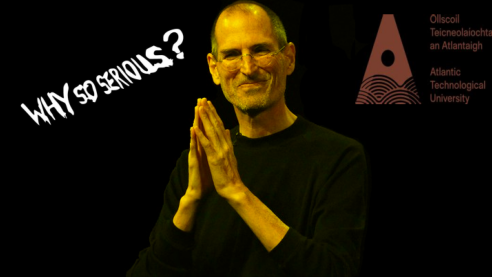

In [ ]:
# code here


#### Student exercise 7
Using the "penguin.jpg" image  <br>
Apply different processing so it looks like the below image <br>
Can you represent the image in any other way?? Do some research and show what you have learned independently  <br> 
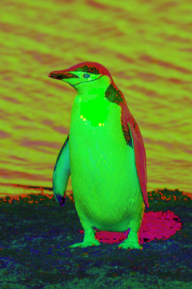

In [ ]:
# Code here

# Student exercise 8
Load an image of your choice <br>
Can you represent the image in any other way?? <br>
Do some research and show what you have learned independently  <br>

In [ ]:
# Code here